<a href="https://colab.research.google.com/github/niruinso/Course_Work/blob/develop/src/KNN_n_Trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
np.random.seed(42)

## Рассмотрим теперь пару моделей, свободных находить не только линейные паттеры. Начнем с метода k-ближайших соседей. Алгоритм регрессии k-ближайших соседей (K-Nearest Neighbors, KNN) основан на гипотезе компактности. Эта гипотеза предполагает, что расположенные близко друг к другу объекты в пространстве признаков имеют схожие значения целевой переменной или принадлежат к одному классу. Сама по себе модель очень проста: она просто запоминает тренировочные данные, а потом делает предсказания при помощи ядерной функции и k-ближайших соседей для нашей точки в тренировочном наборе данных. Соседи находятся как наиболее близкие к нашему объекту точки (простой перебор, однако можно ускорить использованием методов кластеризации). Рассмотрим метрики расстояния:

\begin{equation*}
\textbf{Евклидово расстояние (L2): } d(x, y) = \sqrt{\sum_{i=1}^n(x_i-y_i)^2}
\end{equation*}

\begin{equation*}
\textbf{Манхэттенское расстояние (L1): } d(x, y) = \sum_{i=1}^n|x_i-y_i|
\end{equation*}

\begin{equation*}
\textbf{Расстояние Минковского: } d(x, y) = \left(\sum_{i=1}^n|x_i-y_i|^p\right)^{\frac{1}{p}}
\end{equation*}

## Ядерная функция определяет функцию для предсказания. В классическом KNN все соседи имеют одинаковый вес. Ядерный KNN (kernel-weighted KNN) присваивает каждому соседу вес, зависящий от расстояния до предсказываемой точки. Общая формула предсказания:

\begin{equation*}
\hat{y}(x) = \frac{\sum_{i=1}^{k} K\left(\frac{d(x, x_i)}{h}\right) \cdot y_i}{\sum_{i=1}^{k} K\left(\frac{d(x, x_i)}{h}\right)}
\end{equation*}

## Здесь h - ширина некоторого окна. Она может быть фиксированной - тогда может случиться ситуация, что объект будет определяться меньшим количеством соседей (веса объектов за окном равны нулю), или адаптированной - равной расстоянию до k-го соседа. Приведем некоторые виды ядерных функций:

\begin{equation*}
\textbf{Равномерное ядро (Uniform): } K(u) = \frac{1}{2} \cdot \mathbb{I}(|u| \le 1)
\end{equation*}

\begin{equation*}
\textbf{Треугольное ядро (Triangular): } K(u) = (1-|u|) \cdot \mathbb{I}(|u| \le 1)
\end{equation*}

\begin{equation*}
\textbf{Гауссовское ядро (Gaussian): } K(u) = \frac{1}{\sqrt{2π}} \cdot e^{-\frac{1}{2}u^2}
\end{equation*}

## Вообще говоря, ядерная функция просто должна удовлеторять следующим требованиям:
## 1) Положительность на области определения. Иначе модель будет поощрять несовпадение с некоторыми ближайшими соседями.
## 2) Монотонность не возрастания. Это нужно, чтобы вес близких соседей был больше, чем вес далёких.
## 3) Невозрастание на [0, ∞). Это позволяет свести классификацию объекта к поиску k его ближайших соседей, тогда как при нефинитном ядре (например, гауссовском) требуется перебор всей обучающей выборки, что может приводить к неприемлемым затратам времени на больших выборках.
## Напоследок - перед использованием метода k-ближайших соседей данные следует нормализовать. Расстояние вычисляется как разность координатов, и для данных ненормализованных определенные признаки могут сильно перевешивать другие, из-за чего не удастся использовать в обучении весь набор данных

## Давайте попробуем написать свою версию этого регрессора:

In [2]:
class My_KNN_Regressor:
    def __init__(self, K=5, kernel='uniform', h=None):
        self.K = K
        self.kernel = kernel
        self.h = h

    def fit(self, X_train, y_train):
        self.X_train = np.array(X_train)
        self.y_train = np.array(y_train)
        self.n_samples, self.n_features = X_train.shape

        return self

    def _kernel_function(self, u):
        if self.kernel == 'uniform':
            return np.where(np.abs(u) <= 1, 0.5, 0)

        elif self.kernel == 'triangular':
            return np.where(np.abs(u) <= 1, 1 - np.abs(u), 0)

        elif self.kernel == 'gaussian':
            return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * u**2)

    def _compute_weights(self, distances):
        k_indices = np.argsort(distances)[:self.K]
        k_distances = distances[k_indices]

        if self.h is None:
            h = k_distances[-1]
            if h == 0:
                h = 1e-10
        else:
            h = self.h

        u = k_distances / h

        weights = self._kernel_function(u)

        full_weights = np.zeros(len(distances))
        full_weights[k_indices] = weights

        return full_weights

    def predict_single(self, x):
        distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))

        weights = self._compute_weights(distances)

        return np.sum(weights * self.y_train) / np.sum(weights)

    def predict(self, X_test):
        X_test = np.array(X_test)
        m_test = X_test.shape[0]

        y_predict = np.zeros(m_test)

        for i in range(m_test):
            y_predict[i] = self.predict_single(X_test[i])

        return y_predict

## Для проверки кореектности и сравнения с библиотечной версией модели воспользуемся набором данных california_housing - цены на дома в Калифорнии

In [3]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
X, y = housing.data, housing.target

In [4]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [5]:
y

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422
...,...
20635,0.781
20636,0.771
20637,0.923
20638,0.847


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=scaler.get_feature_names_out())
X_test = pd.DataFrame(scaler.transform(X_test), columns=scaler.get_feature_names_out())

In [7]:
myKNN = My_KNN_Regressor()
myKNN.fit(X_train, y_train)

In [8]:
from sklearn.metrics import root_mean_squared_error as rmse, mean_absolute_error as mae, r2_score as r2

y_pred = myKNN.predict(X_test)
print(f"RMSE: {rmse(y_pred, y_test)}, MAE: {mae(y_pred, y_test)}, R2-score: {r2(y_test, y_pred)}")

RMSE: 0.6575877238850522, MAE: 0.4461535271317829, R2-score: 0.6700101862970989


## Давайте посмотрим на результативность библиотечной модели

In [9]:
from sklearn.neighbors import KNeighborsRegressor

SklearnKNN = KNeighborsRegressor()
SklearnKNN.fit(X_train, y_train)

KNeighborsRegressor()

In [10]:
def show_comparison(my_model, sklearn_model, types_of_comparing):
    print(types_of_comparing)
    my_model_prediction = my_model.predict(X_test)
    sklearn_model_prediction = sklearn_model.predict(X_test)
    print(f"MAE: My Model: {mae(y_test, my_model_prediction)} vs Sklearn: {mae(y_test, sklearn_model_prediction)}")
    print(f"RMSE: My Model: {rmse(y_test, my_model_prediction)} vs Sklearn: {rmse(y_test, sklearn_model_prediction)}")
    print(f"R-Squared: My Model: {r2(y_test, my_model_prediction)} vs Sklearn: {r2(y_test, sklearn_model_prediction)}")

In [11]:
show_comparison(myKNN, SklearnKNN, "K-Nearest Neighbors")

K-Nearest Neighbors
MAE: My Model: 0.4461535271317829 vs Sklearn: 0.4461535271317829
RMSE: My Model: 0.6575877238850522 vs Sklearn: 0.6575877238850522
R-Squared: My Model: 0.6700101862970989 vs Sklearn: 0.6700101862970989


## Хороший результат. Давайте посмотрим на графике отклонение от предсказаний

In [12]:
def vizual_pred_test(y_test, y_pred, title):
    plt.figure(figsize=(10, 10))

    plt.scatter(y_test, y_pred, alpha=0.3, s=10, c='blue', label='Предсказания')

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='y = x')

    plt.xlabel('Тестовые данные', fontsize=12)
    plt.ylabel('Предсказанные точки', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')

    plt.tight_layout()
    plt.show()

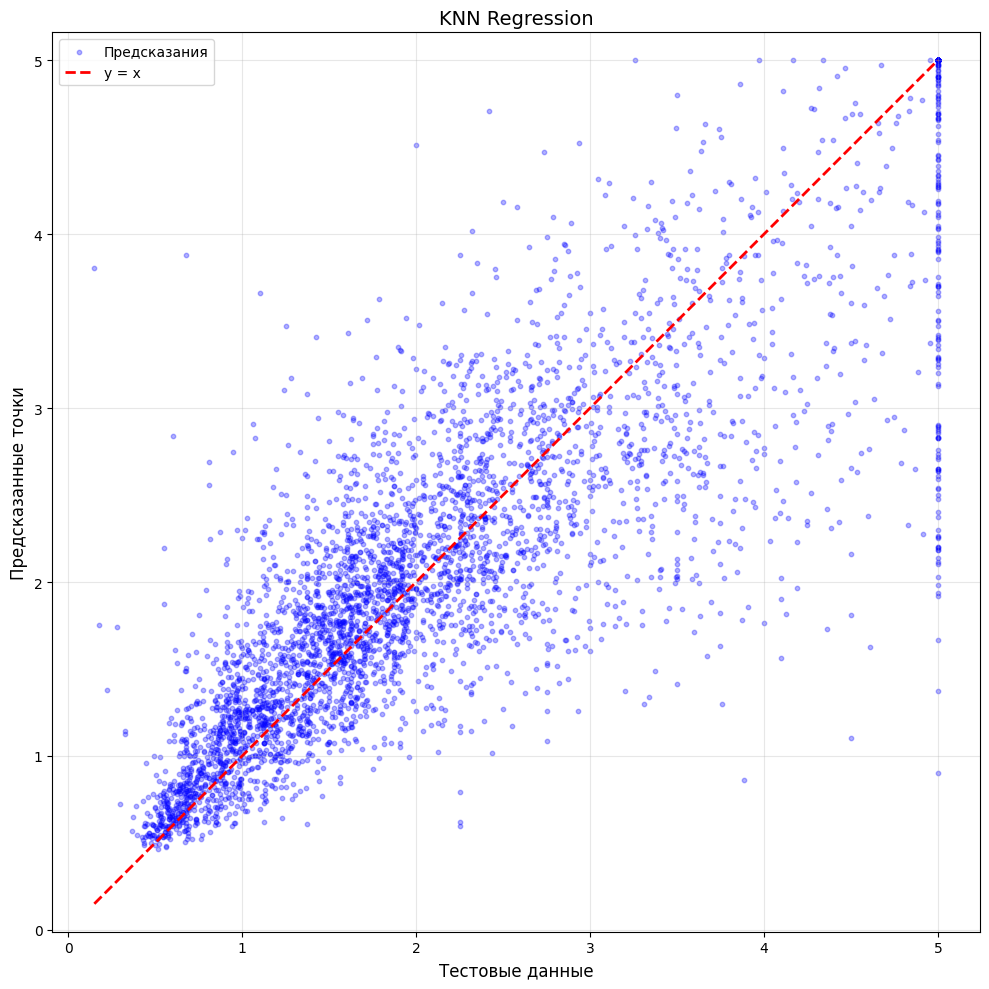

In [13]:
vizual_pred_test(y_test, y_pred, 'KNN Regression')

In [14]:
myKNN = My_KNN_Regressor(kernel='gaussian')
myKNN.fit(X_train, y_train)

In [15]:
y_pred = myKNN.predict(X_test)
print(f"RMSE: {rmse(y_pred, y_test)}, MAE: {mae(y_pred, y_test)}, R2-score: {r2(y_test, y_pred)}")

RMSE: 0.6560461334103407, MAE: 0.44466613099799507, R2-score: 0.6715555705819223


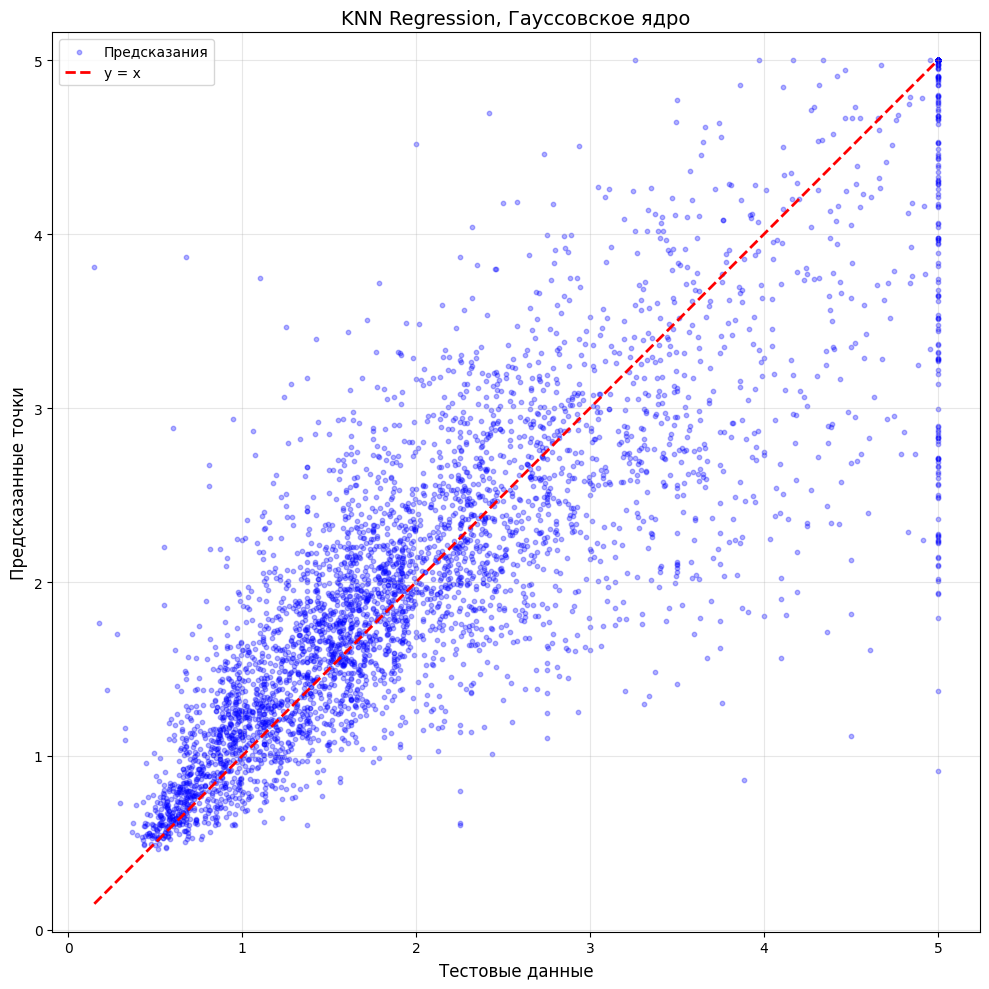

In [16]:
vizual_pred_test(y_test, y_pred, 'KNN Regression, Гауссовское ядро')

In [17]:
myKNN = My_KNN_Regressor(kernel='triangular')
myKNN.fit(X_train, y_train)

In [18]:
y_pred = myKNN.predict(X_test)
print(f"RMSE: {rmse(y_pred, y_test)}, MAE: {mae(y_pred, y_test)}, R2-score: {r2(y_test, y_pred)}")

RMSE: 0.6892594152060683, MAE: 0.4601691260346224, R2-score: 0.6374578094787176


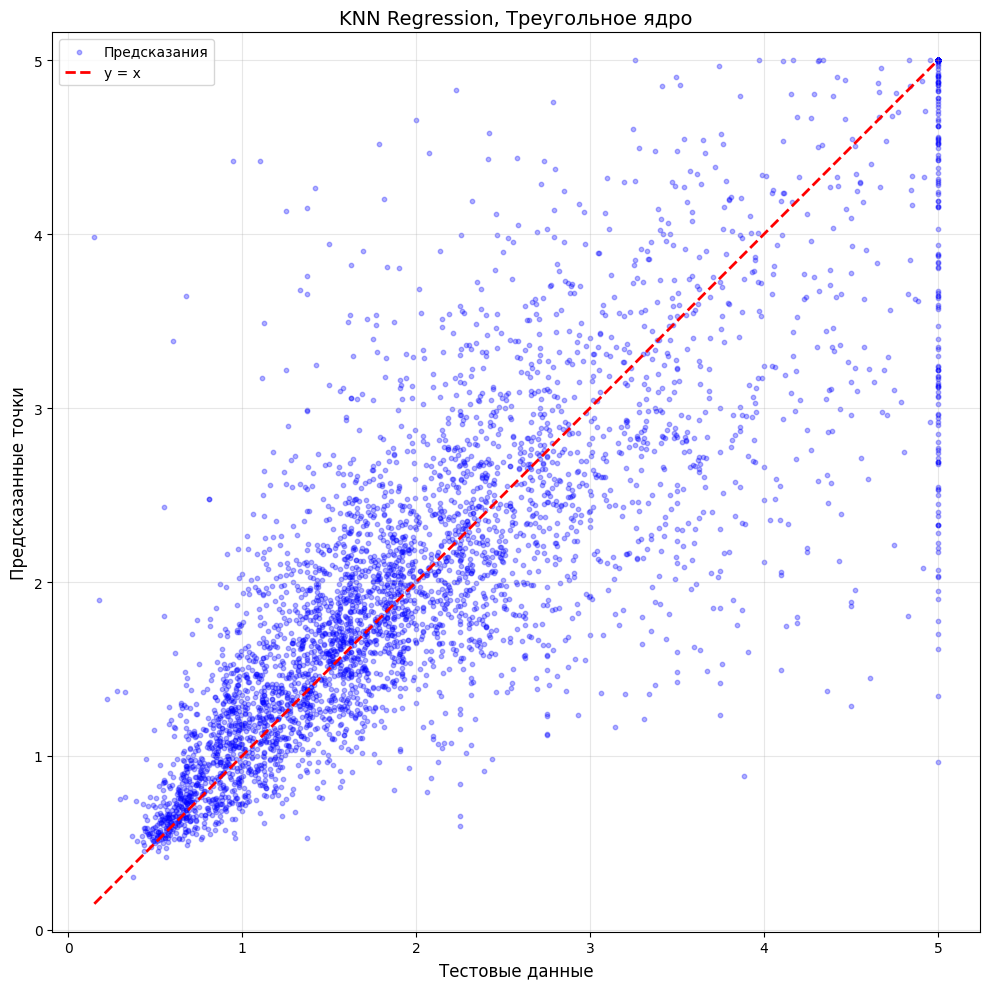

In [19]:
vizual_pred_test(y_test, y_pred, 'KNN Regression, Треугольное ядро')

## Рассмотрим также и обучаемость модели

In [26]:
def plot_learning_curves(model, start=1, step_size=1):
    train_errors, test_errors = [], []
    for m in range(start, len(X_train), step_size):
        model.fit(X_train[:m], y_train[:m])
        y_train_pred = model.predict(X_train[:m])
        y_test_pred = model.predict(X_test)
        train_errors.append(rmse(y_train_pred, y_train[:m]))
        test_errors.append(rmse(y_test_pred, y_test))
    plt.plot(train_errors, "r--", linewidth=2, label="train")
    plt.plot(test_errors, "b-", linewidth=3, label="test")
    plt.legend(loc='best')

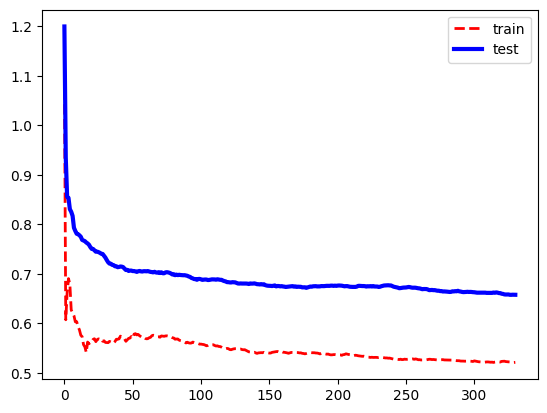

In [27]:
plot_learning_curves(SklearnKNN, start=5,  step_size=50)

## Следующая модель - дерево принятия решений. С учетом нашей задачи будем рассматривать именно версию для регрессии. Итак, рекурсивно к дереву принятия решений добавляются ветки следующим образом: выбирается признак, по которому делятся данные, и какая-нибудь граница так, что значения больше попадают в правое поддерево, и наоборот, значения признака меньше этой границы попадают в левое поддерево. Алгоритм жадный: признак и граница выбираются так, чтобы средняя квадратическая ошибка была наименьшей (для всех объектов, попавших в определенный узел, вычисляется среднее значение по целевому признаку - это и будет решение дерева на конкретном узле). Однако хотелось бы контролировать рост дерева. Поэтому есть параметры, контролирующие разбиение на поддеревья, и при определенных условиях рост прекращается. Среди них:
## ⋅ max_depth - максимальная глубина дерева
## ⋅ min_samples_split - минимальное число образцов, которые должны присутствовать в узле, прежде чем его можно будет расщепить
## ⋅ min_samples_leaf - минимальное количество образцов, которое должен иметь листовой узел
## ⋅ max_leaf_nodes - максимальное количество листовых узлов
## ⋅ min_weight_fraction_leaf - min_samples_leaf, только выраженное в долях от общего числа взвешенных образцов
## ⋅ max_features - максимальное число признаков, которые оцениваются при расщеплении каждого узла
## Примечание: окончательное решение дерева по объекту принимается в листовом узле. Приведем следующую (простую) реализацию дерева принятия решений для регрессионной задачи:

In [28]:
class Node():
    def __init__(self, X, y, right=None, left=None, feature=None, threshold=None, value=None, method='gini', class_counts=None):
        self.X = X
        self.y = y
        self.right = right
        self.left = left
        self.method = method
        self.feature = feature
        self.threshold = threshold
        self.value = value
        self.class_counts = class_counts

    def mse(self, y):
        return np.mean((y - np.mean(y)) ** 2)

    def information_gain(self, left_y, right_y):
        n_left, n_right = len(left_y), len(right_y)
        n_total = n_left + n_right

        if n_total == 0:
            return 0

        score = None

        left_mse = self.mse(left_y)
        right_mse = self.mse(right_y)

        score = (n_left / n_total) * left_mse + (n_right / n_total) * right_mse

        return score

    def is_leaf_node(self):
        return self.value is not None

In [29]:
def best_split(node):
    X, y = node.X, node.y

    features = X.columns
    best_gain = np.inf
    best_feature, best_threshold = None, None

    for feature in features:
        unique_feature_values = np.unique(X[feature])

        for i in range(len(unique_feature_values)):
            threshold = unique_feature_values[i]
            feature_values = X[feature]

            left_idxs = np.where(feature_values <= threshold)[0]
            right_idxs = np.where(feature_values > threshold)[0]

            left_labels, right_labels = y[left_idxs], y[right_idxs]

            gain = node.information_gain(left_labels, right_labels)

            if gain <= best_gain:
                best_gain = gain
                best_feature = feature
                best_threshold = threshold

    return best_feature, best_threshold

In [30]:
class MyDecisionTreeRegressor:
    def __init__(self, max_depth=10, min_samples_split=2, min_samples_leaf=1):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.root = None
        self.n_classes_ = None
        self.feature_names_ = None

    def fit(self, X, y):
        if hasattr(y, 'values'):
            y = y.values
        self.feature_names_ = X.columns.tolist()
        self.n_classes_ = len(np.unique(y))

        self.root = self._grow_tree(X, y)
        return self

    def _grow_tree(self, X, y, depth=0):
        node = Node(X, y, method='mse')
        n_samples = len(y)

        if depth >= self.max_depth or n_samples < self.min_samples_split:
            node.value = np.mean(y)
            return node

        feature, threshold = best_split(node)
        if feature is None:
            node.value = np.mean(y)
            return node

        feature_values = X[feature]
        left_idxs = np.where(feature_values <= threshold)[0]
        right_idxs = np.where(feature_values > threshold)[0]

        if len(left_idxs) < self.min_samples_leaf or len(right_idxs) < self.min_samples_leaf:
            node.value = np.mean(y)
            return node

        left_X = X.iloc[left_idxs]
        right_X = X.iloc[right_idxs]
        left_y = y[left_idxs]
        right_y = y[right_idxs]

        node.feature = feature
        node.threshold = threshold
        node.left = self._grow_tree(left_X, left_y, depth + 1)
        node.right = self._grow_tree(right_X, right_y, depth + 1)

        return node

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for _, x in X.iterrows()])

    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value
        feature_value = x[node.feature]
        if feature_value <= node.threshold:
            return self._traverse_tree(x, node.left)
        else:
            return self._traverse_tree(x, node.right)

    def predict_proba(self, X):
        return np.array([self._proba_tree(x, self.root) for _, x in X.iterrows()])

    def _proba_tree(self, x, node):
        if node.value is not None:
            total = node.class_counts.sum()
            if total == 0:
                return np.array([0.5, 0.5])
            return node.class_counts / total
        return self._proba_tree(x, node.left if x[node.feature] <= node.threshold else node.right)

## Проделаем то же, что и для метода k-ближайших соседей

In [31]:
myTree = MyDecisionTreeRegressor()
myTree.fit(X_train, y_train)

In [32]:
y_pred = myTree.predict(X_test)
print(f"RMSE: {rmse(y_pred, y_test)}, MAE: {mae(y_pred, y_test)}, R2-score: {r2(y_test, y_pred)}")

RMSE: 0.6516318060785196, MAE: 0.4361187391139393, R2-score: 0.6759606979622721


## Сравним с библиотекой из sklearn

In [33]:
from sklearn.tree import DecisionTreeRegressor

SklearnTree = DecisionTreeRegressor(max_depth=10, min_samples_split=2, min_samples_leaf=1)
SklearnTree.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=10)

In [34]:
show_comparison(myTree, SklearnTree, "DesicionTreeRegressor")

DesicionTreeRegressor
MAE: My Model: 0.4361187391139393 vs Sklearn: 0.43304429526573723
RMSE: My Model: 0.6516318060785196 vs Sklearn: 0.644241830361174
R-Squared: My Model: 0.6759606979622721 vs Sklearn: 0.683268702459382


## Получилось получше, чем с KNN. Рассмотрим графики

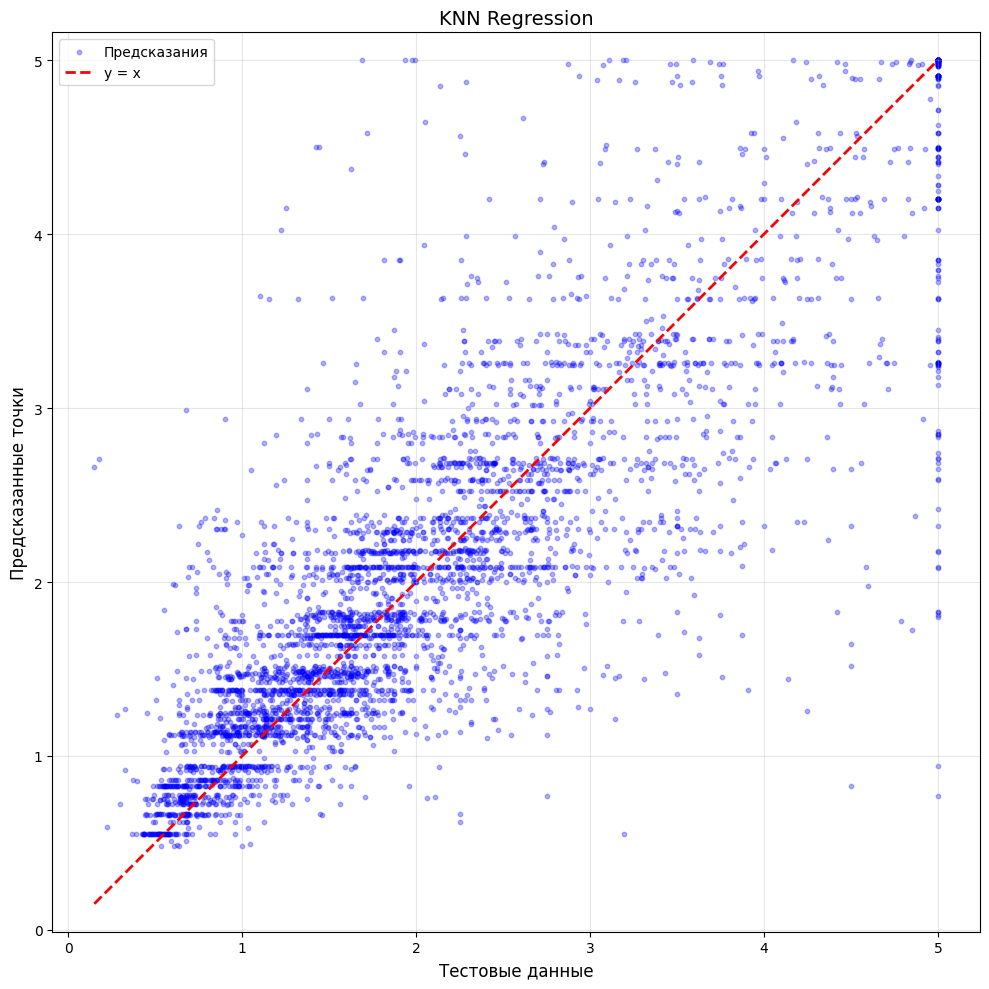

In [35]:
vizual_pred_test(y_test, y_pred, 'KNN Regression')

## На самом деле, деревья принятия решений - очень простая и при этом простая для интерпретации модель. Дело в том, что все предсказания строятся на дереве, а значит, можно отрисовать это дерево и посмотреть, как получаются эти предсказания

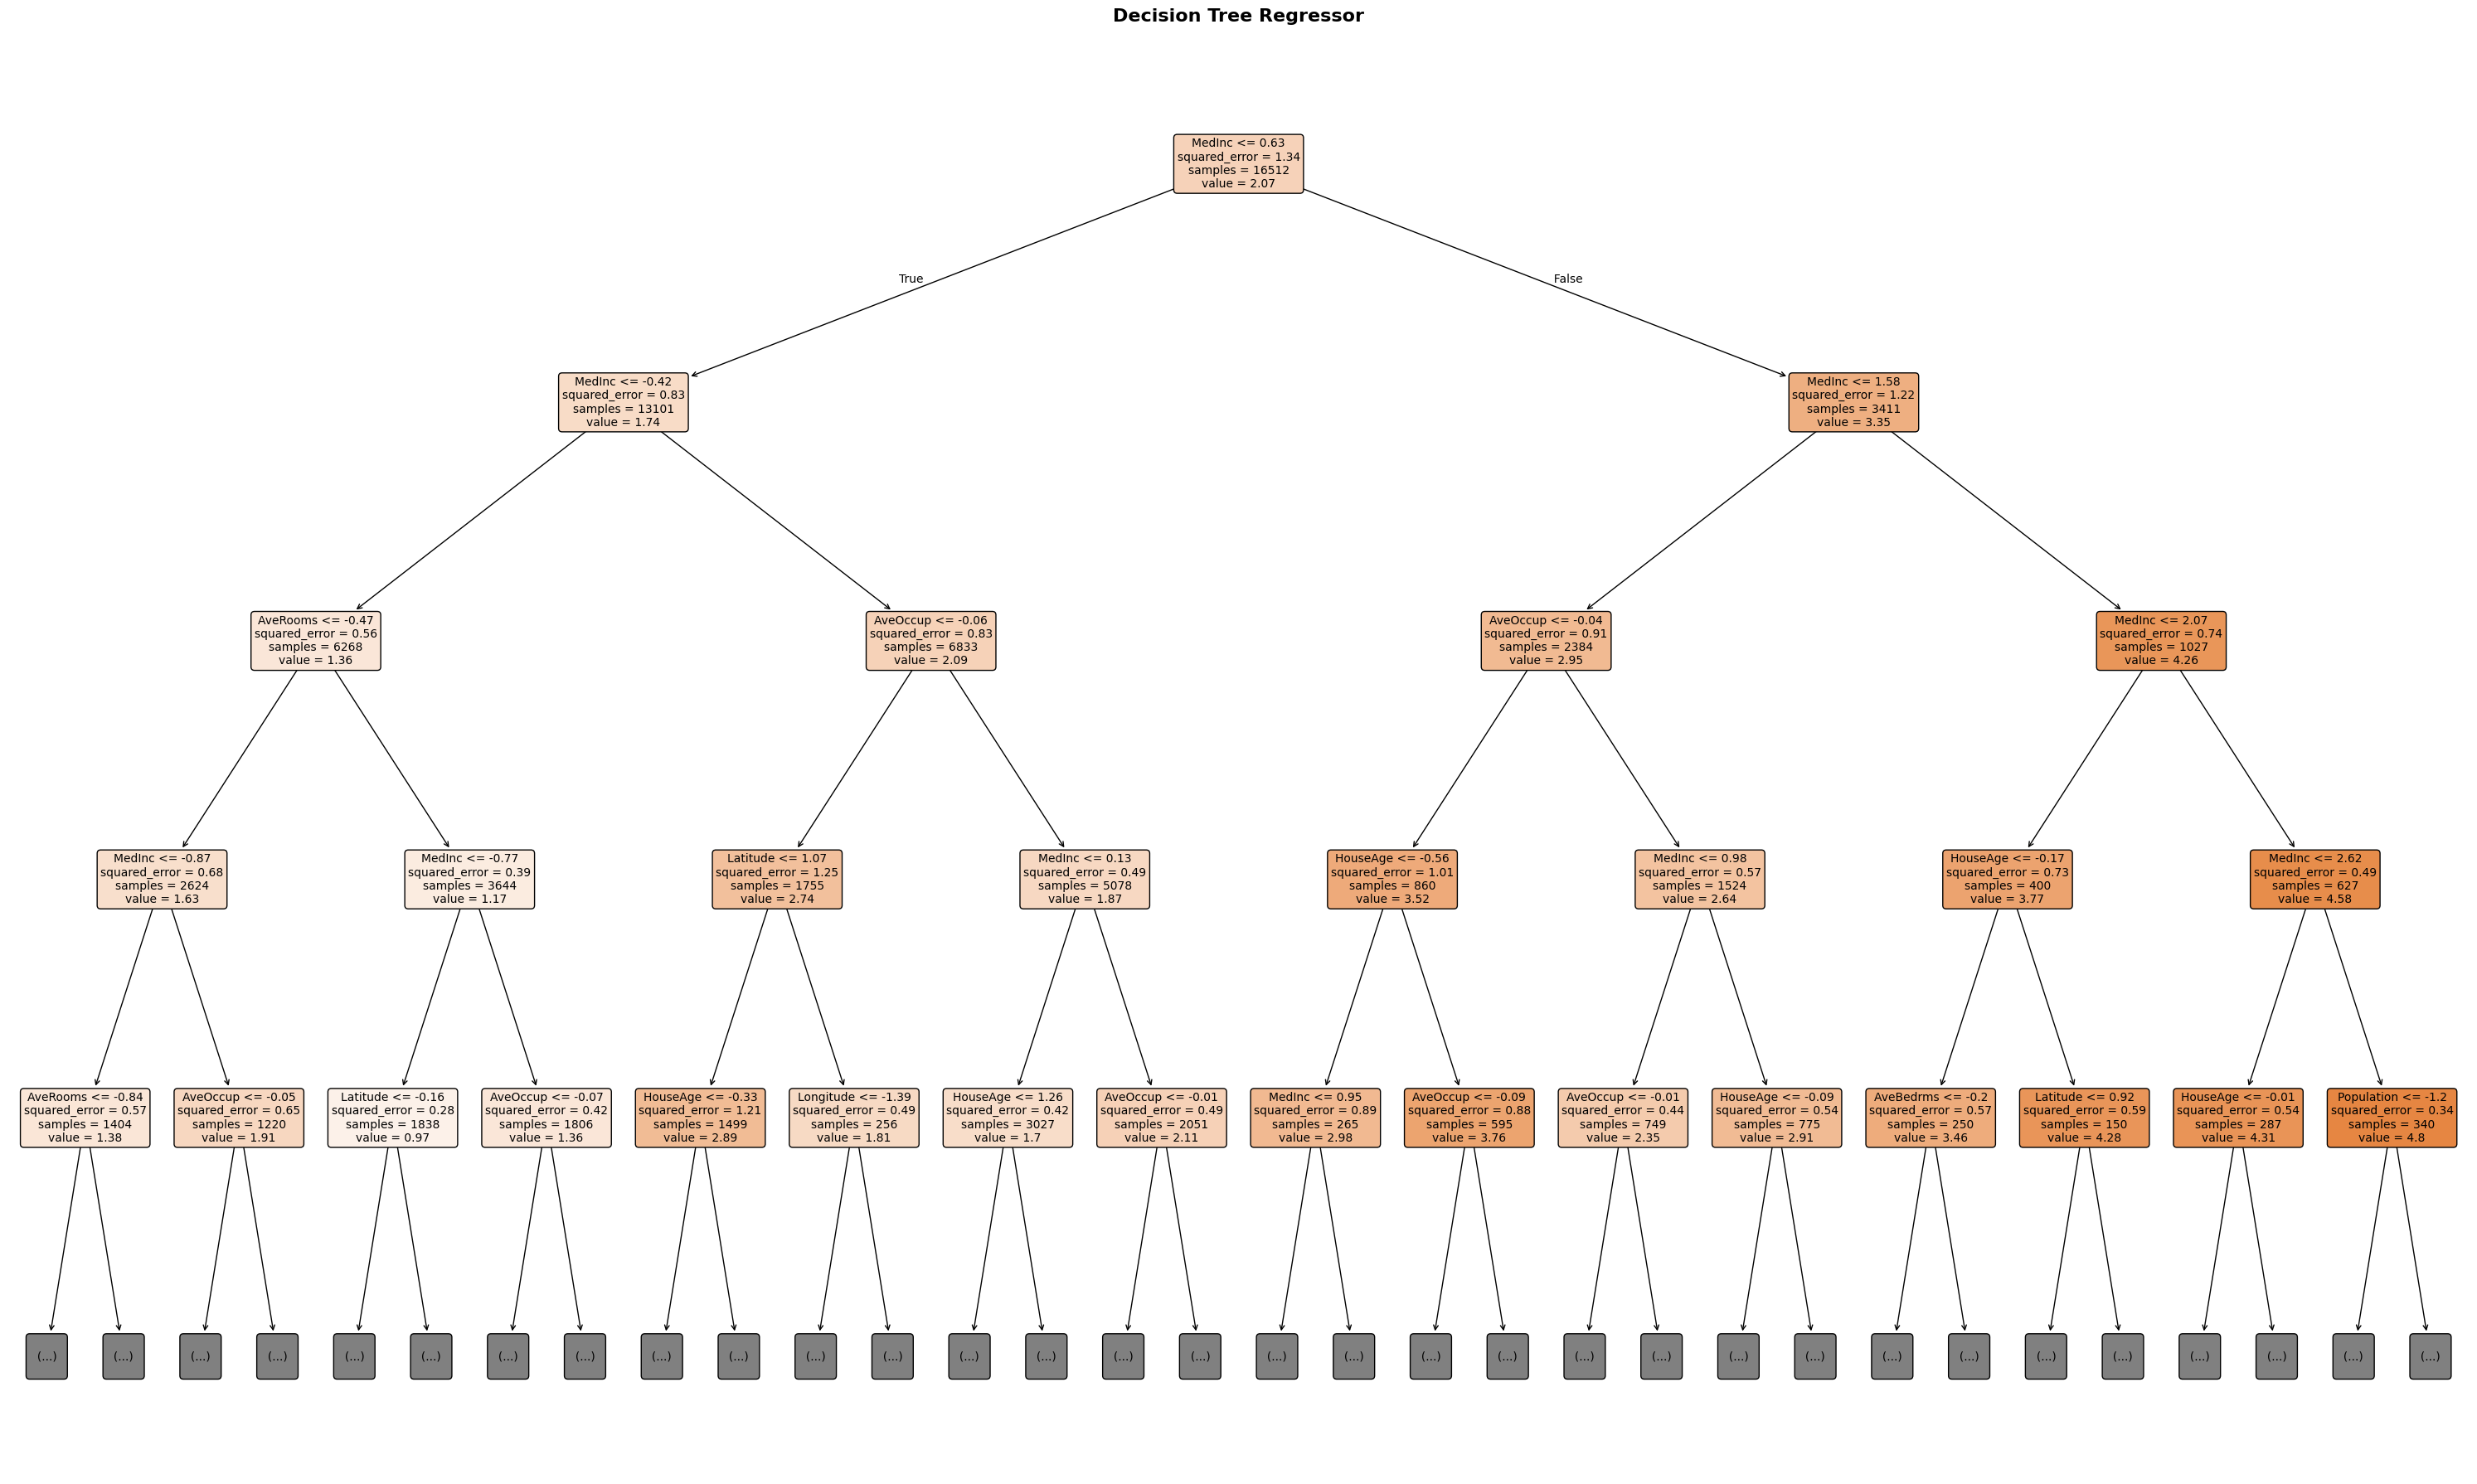

In [36]:
from sklearn.tree import plot_tree

plt.figure(figsize=(30, 18))

plot_tree(
    SklearnTree,
    feature_names=housing.feature_names,
    filled=True,
    rounded=True,
    precision=2,
    fontsize=10,
    impurity=True,
    node_ids=False,
    proportion=False,
    max_depth=4
)

plt.title('Decision Tree Regressor', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## Вернемся к нашей задаче: предсказание предполагаемого результата за экзамен. Загрузим тренировочные и валидационные данные

In [37]:
import pandas as pd

train_df = pd.read_csv("data/Train.csv")
valid_df = pd.read_csv("data/Valid.csv")

In [38]:
X_train = train_df.drop('Exam_Score', axis=1)
X_valid = valid_df.drop('Exam_Score', axis=1)

y_train = train_df['Exam_Score']
y_valid= valid_df['Exam_Score']

In [39]:
from sklearn.model_selection import GridSearchCV

## Начнем с метода k-ближайших соседей

In [52]:
model = KNeighborsRegressor()

knn_params = {
    'n_neighbors': [3, 5, 7, 10, 15, 20, 25, 30],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
    'p': [1, 2]
}

grid_search = GridSearchCV(model, knn_params, cv=3, verbose=2, scoring="neg_mean_squared_error")
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

best_knn_model = grid_search.best_estimator_

Fitting 3 folds for each of 64 candidates, totalling 192 fits
[CV] END metric=euclidean, n_neighbors=3, p=1, weights=uniform; total time=   0.0s
[CV] END metric=euclidean, n_neighbors=3, p=1, weights=uniform; total time=   0.0s
[CV] END metric=euclidean, n_neighbors=3, p=1, weights=uniform; total time=   0.0s
[CV] END metric=euclidean, n_neighbors=3, p=1, weights=distance; total time=   0.1s
[CV] END metric=euclidean, n_neighbors=3, p=1, weights=distance; total time=   0.0s
[CV] END metric=euclidean, n_neighbors=3, p=1, weights=distance; total time=   0.0s
[CV] END metric=euclidean, n_neighbors=3, p=2, weights=uniform; total time=   0.0s
[CV] END metric=euclidean, n_neighbors=3, p=2, weights=uniform; total time=   0.0s
[CV] END metric=euclidean, n_neighbors=3, p=2, weights=uniform; total time=   0.0s
[CV] END metric=euclidean, n_neighbors=3, p=2, weights=distance; total time=   0.0s
[CV] END metric=euclidean, n_neighbors=3, p=2, weights=distance; total time=   0.0s
[CV] END metric=eucl

## И для дерева принятия решений

In [41]:
model = DecisionTreeRegressor(random_state=42)

dt_params = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20, 50],
    'min_samples_leaf': [1, 2, 5, 10, 20],
    'max_features': ['sqrt', 'log2', None, 0.5, 0.7],
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error']
}

grid_search = GridSearchCV(model, dt_params, cv=3, verbose=2)
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

best_tree_model = grid_search.best_estimator_

Выходные данные были обрезаны до нескольких последних строк (5000).
[CV] END criterion=friedman_mse, max_depth=3, max_features=0.5, min_samples_leaf=2, min_samples_split=50; total time=   0.0s
[CV] END criterion=friedman_mse, max_depth=3, max_features=0.5, min_samples_leaf=2, min_samples_split=50; total time=   0.0s
[CV] END criterion=friedman_mse, max_depth=3, max_features=0.5, min_samples_leaf=2, min_samples_split=50; total time=   0.0s
[CV] END criterion=friedman_mse, max_depth=3, max_features=0.5, min_samples_leaf=5, min_samples_split=2; total time=   0.0s
[CV] END criterion=friedman_mse, max_depth=3, max_features=0.5, min_samples_leaf=5, min_samples_split=2; total time=   0.0s
[CV] END criterion=friedman_mse, max_depth=3, max_features=0.5, min_samples_leaf=5, min_samples_split=2; total time=   0.0s
[CV] END criterion=friedman_mse, max_depth=3, max_features=0.5, min_samples_leaf=5, min_samples_split=5; total time=   0.0s
[CV] END criterion=friedman_mse, max_depth=3, max_features=0.

## Рассмотрим точность моделей на валидационных данных

In [42]:
def show_scores(model, model_name):
    y_pred = model.predict(X_valid)
    print(f"Scoring of {model_name} Model")
    print(f"RMSE: {rmse(y_valid, y_pred)}")
    print(f"MAE: {mae(y_valid, y_pred)}")
    print(f"R2: {r2(y_valid, y_pred)}\n")

In [53]:
show_scores(best_knn_model, "KNN")
show_scores(best_tree_model, "DesicionTree")

Scoring of KNN Model
RMSE: 2.9993711894587562
MAE: 1.7952465210059523
R2: 0.43079210258531486

Scoring of DesicionTree Model
RMSE: 2.8368876224556336
MAE: 1.4994954591321896
R2: 0.490792547835882



## Рассмотрим обучаемость наших моделей

In [49]:
def plot_learning_curves(model, start=1, step_size=10):
    train_errors, valid_errors = [], []
    for m in range(start, len(X_train), step_size):
        model.fit(X_train[:m], y_train[:m])
        y_train_pred = model.predict(X_train[:m])
        y_valid_pred = model.predict(X_valid)
        train_errors.append(rmse(y_train_pred, y_train[:m]))
        valid_errors.append(rmse(y_valid_pred, y_valid))
    plt.plot(train_errors, "r--", linewidth=2, label="train")
    plt.plot(valid_errors, "b-", linewidth=3, label="valid")
    plt.legend(loc='best')

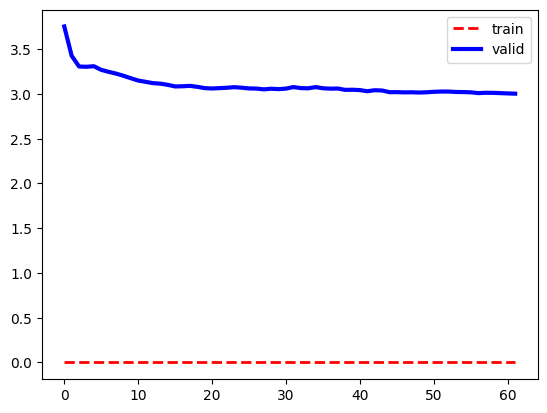

In [54]:
plot_learning_curves(best_knn_model, start=20, step_size=75)

## Не стоит удивляться такому графику. Все же обучение knn - это простое запоминание тренировочных данных, а значит, модель знает все ответы, так что ошибок быть не может. Это не переобучение

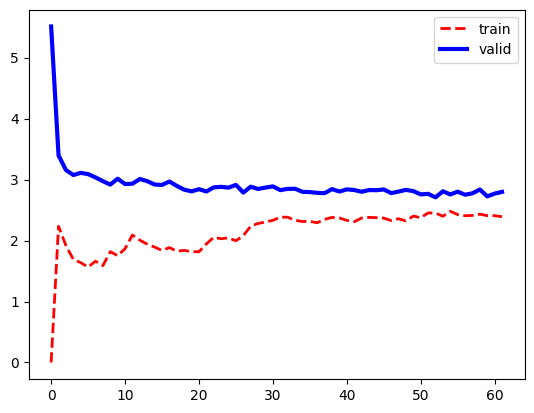

In [55]:
plot_learning_curves(best_tree_model, step_size=75)

## Тоже нет переобучения

## И не забываем об отклонениях предсказаний

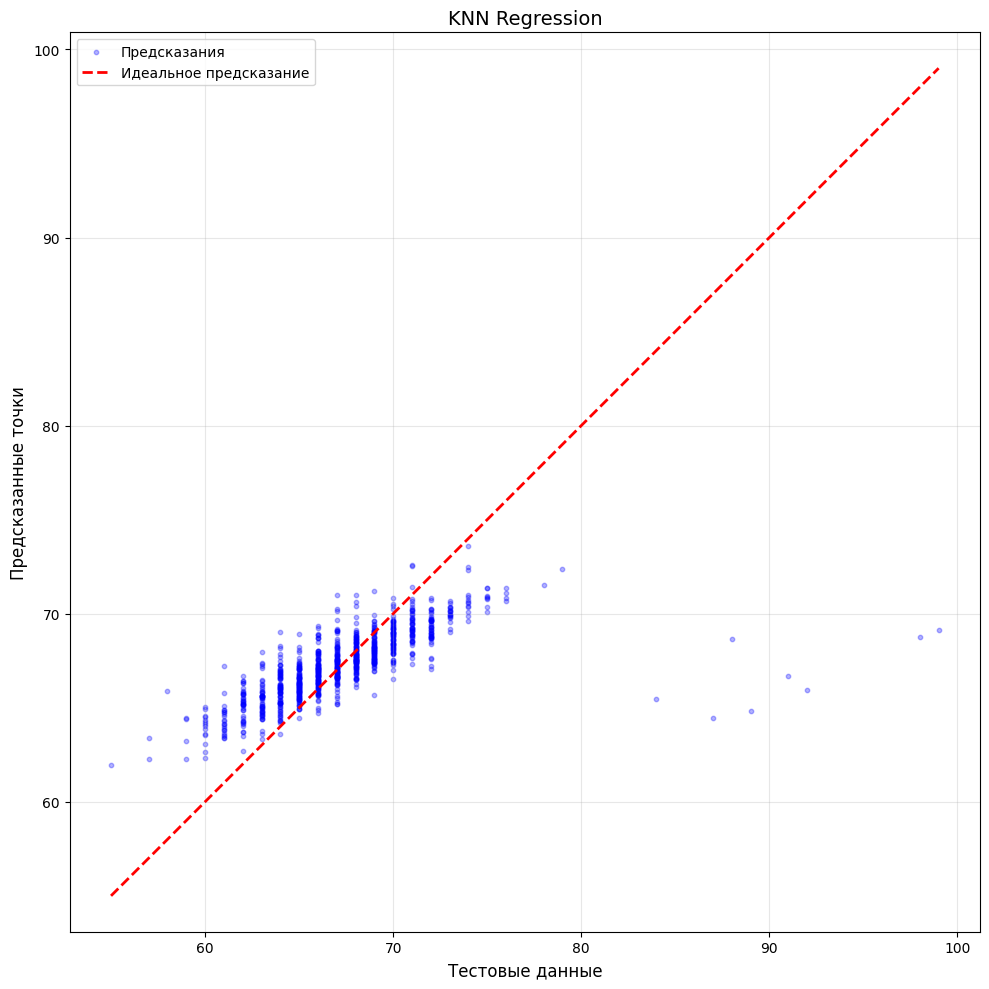

In [57]:
vizual_pred_test(y_valid, best_knn_model.predict(X_valid), "KNN Regression")

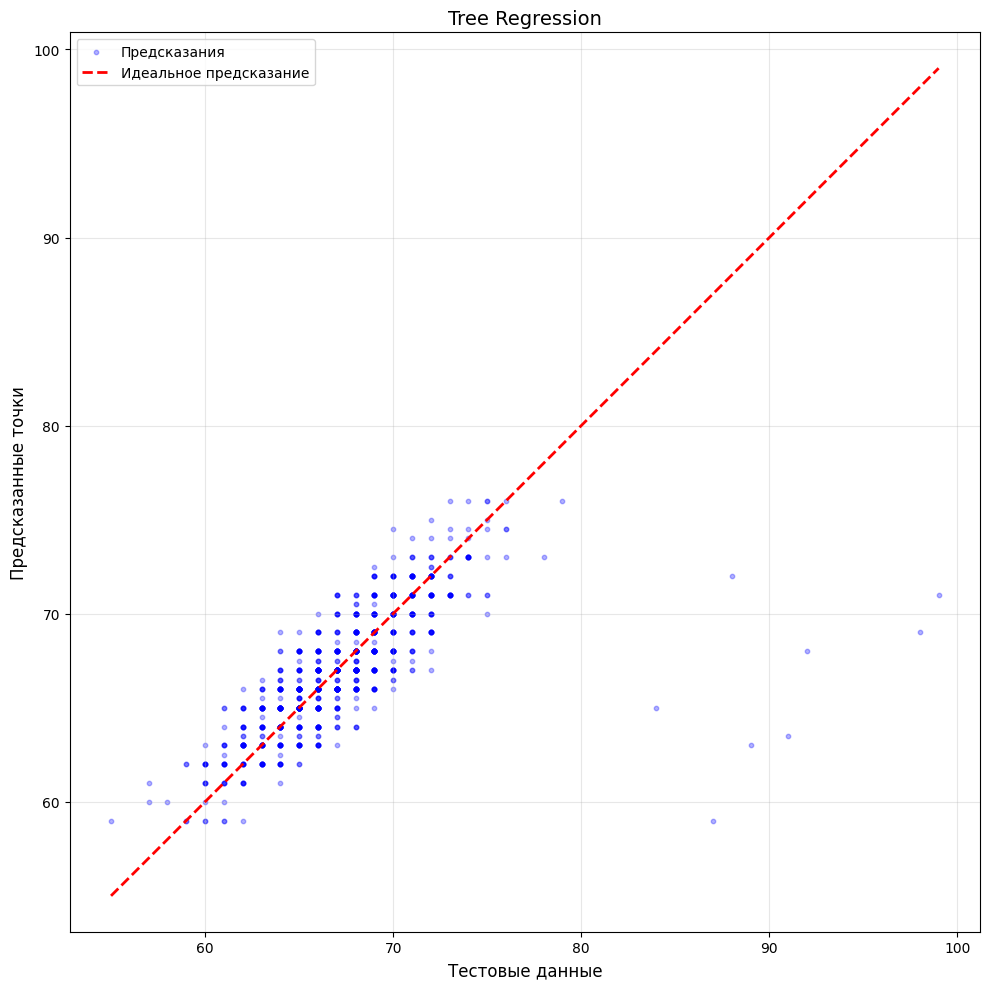

In [58]:
vizual_pred_test(y_valid, best_tree_model.predict(X_valid), "Tree Regression")

## Давайте сохраним эти результаты

In [59]:
results_tree_knn = pd.DataFrame(columns=['model', 'params', 'MAE', 'RMSE', 'R2'])

In [60]:
def resulting(model, df, model_name):
    prediction = model.predict(df)
    row = {'model': model_name,
                  'params': model.get_params(),
                  'MAE': mae(y_valid, prediction),
                  'RMSE': rmse(y_valid, prediction),
                  'R2': r2(y_valid, prediction)}
    results_tree_knn.loc[len(results_tree_knn)] = row

In [61]:
resulting(best_knn_model, X_valid, "KNN")
resulting(best_tree_model, X_valid, "DesicionTree")

In [62]:
results_tree_knn.to_csv("data/results_tree_knn.csv")